In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [19]:
df = pd.read_csv('datasets/purchase_data.csv')  # Load the dataset
df.head()

,age,income,previous_purchases,purchase
0,56,54674,15,1
1,69,55854,13,1
2,46,66271,15,1
3,32,93688,4,1
4,60,58518,8,1


In [20]:
df["purchase"].unique()  # Check the unique values in the purchase column

array([1, 0], dtype=int64)

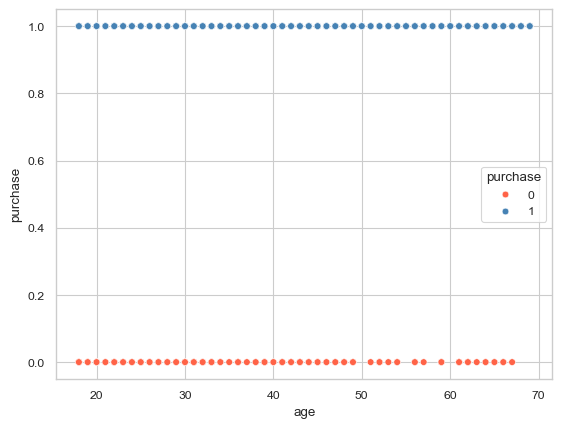

In [21]:
custom_palette = sns.color_palette(["#FF6347", "#4682B4", "#FFD700", "#6A5ACD"])

sns.set_theme(style="whitegrid", context='paper' ,palette=custom_palette)
sns.scatterplot(x='age', y='purchase',hue='purchase', data=df)  # Scatter plot of age vs purchase
plt.show()

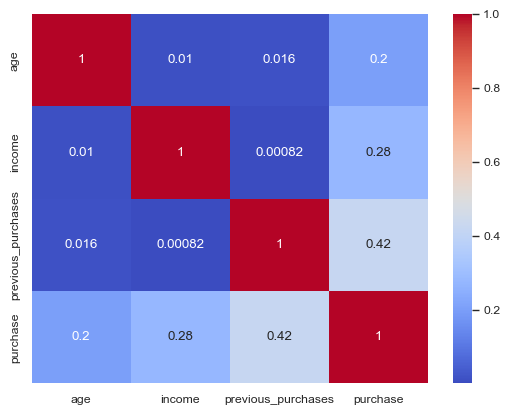

In [22]:
  # Set the theme for the plots
correlation = df.corr()  # Calculate the correlation matrix
sns.heatmap(correlation, annot=True, cmap='coolwarm')  # Plot the correlation matrix
plt.show()

<Axes: xlabel='income', ylabel='purchase'>

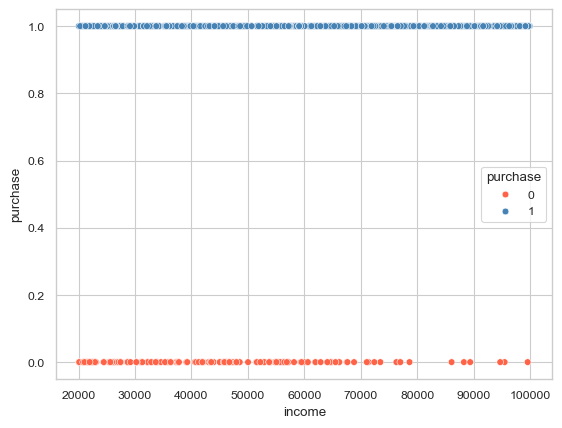

In [23]:
sns.scatterplot(x='income', y='purchase', data=df, hue='purchase')  # Scatter plot of salary vs purchase

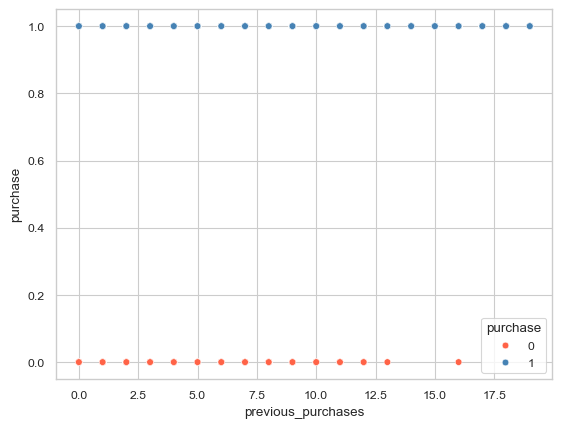

In [24]:
sns.scatterplot(x='previous_purchases', y='purchase', data=df, hue='purchase')  # Scatter plot of salary vs purchase
plt.show()

In [25]:
x = df.iloc[:, :-1]  # Features 
y = df['purchase']  # Target

# Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [26]:
lr = LogisticRegression()  # Create a logistic regression model
lr.fit(x_train, y_train)  # Fit the model

LogisticRegression()

In [27]:
lr.score(x_test, y_test)*100  # Check the accuracy of the model

89.0

In [28]:
lr.predict(x_test)  # Predict the purchase

array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1], dtype=int64)

In [29]:
# mean sqyaured error
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, lr.predict(x_test))

0.11

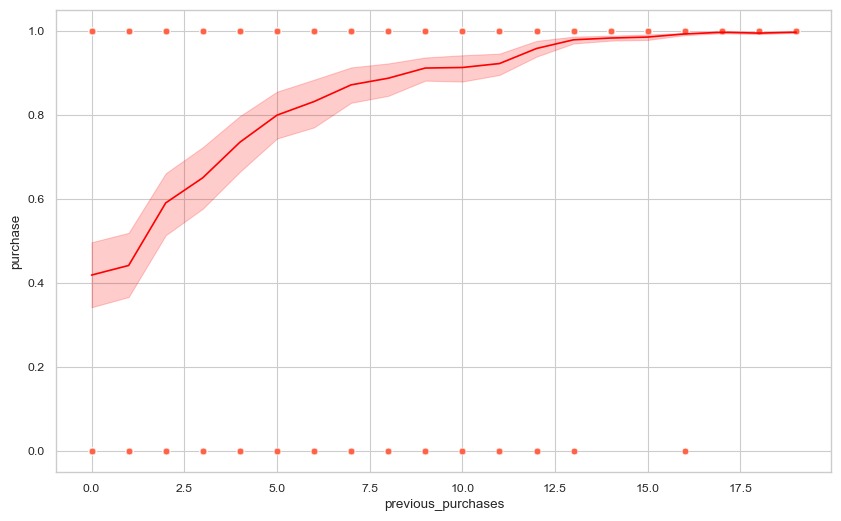

In [30]:
# 0.11 means that the model is 89% accurate
# getting the sigmoid curve
plt.figure(figsize=(10, 6))
sns.scatterplot(x='previous_purchases', y='purchase', data=df)
sns.lineplot(x=df['previous_purchases'], y=lr.predict_proba(x)[:, 1], color='red', data=df)
plt.show()

In [31]:
# predicting the values
lr.predict([[56,54674,15]])

c:\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [32]:
# df[df['purchase'] == 0].head()  # Descriptive statistics of the purchase column
lr.predict([[25,30267,1]])

c:\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0], dtype=int64)

In [33]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.to_numpy(), y.to_numpy(), classifier=lr)
plt.show()

ModuleNotFoundError: No module named 'mlxtend.plotting'